In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans
# for elbow
import kneed 
from kneed import KneeLocator

In [ ]:
df = pd.read_csv("mall customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = df.rename(columns={"Annual Income (k$)":"income", "Spending Score (1-100)":"score"})

In [ ]:
df.head()

,CustomerID,Gender,Age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
new_df = df.copy()

In [ ]:
df.isna().sum()

CustomerID    0
Gender        0
Age           0
income        0
score         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

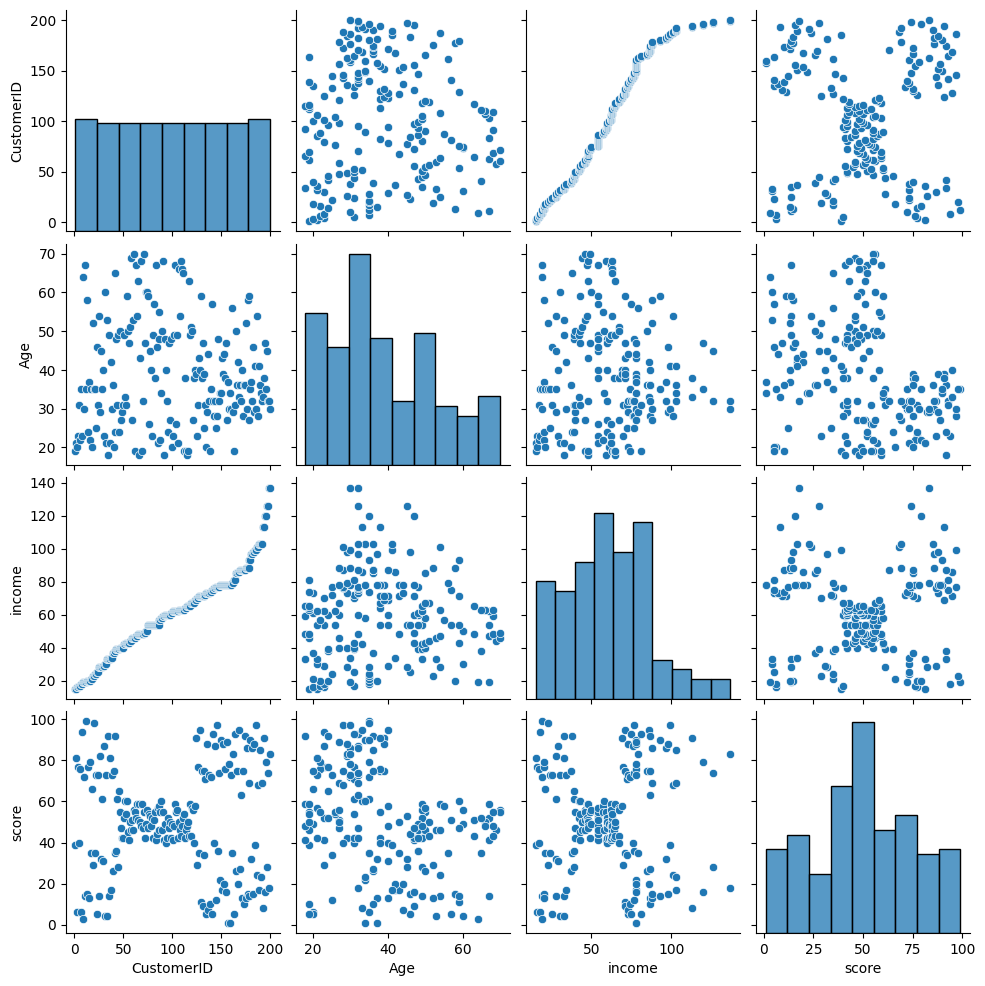

In [ ]:
sns.pairplot(df)

<Axes: xlabel='income', ylabel='score'>

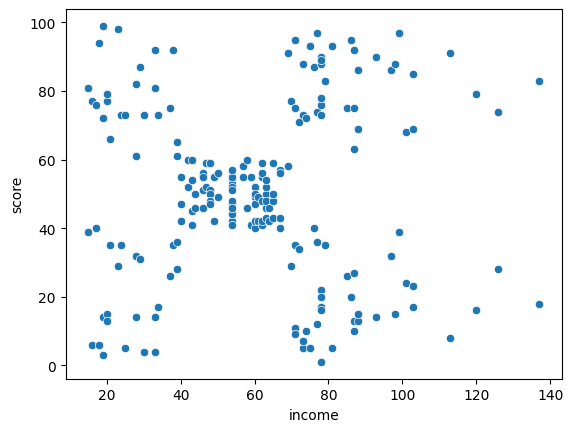

In [ ]:
sns.scatterplot(x = df["income"], y = df["score"])

In [ ]:
# model implementation
km = KMeans() # default 8 class
model = km.fit(df[["income", "score"]])

In [ ]:
df["pred"] = model.predict(df[["income", "score"]])

In [ ]:
df.head()

,CustomerID,Gender,Age,income,score,pred
0,1,Male,19,15,39,7
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,7


In [ ]:
df[df["pred"] == 0]

,CustomerID,Gender,Age,income,score,pred
179,180,Male,35,93,90,0
181,182,Female,32,97,86,0
183,184,Female,29,98,88,0
185,186,Male,30,99,97,0
187,188,Male,28,101,68,0
189,190,Female,36,103,85,0
191,192,Female,32,103,69,0
193,194,Female,38,113,91,0
195,196,Female,35,120,79,0
197,198,Male,32,126,74,0


In [ ]:
df0 = df[df["pred"] == 0]
df1 = df[df["pred"] == 1]
df2 = df[df["pred"] == 2]
df3 = df[df["pred"] == 3]
df4 = df[df["pred"] == 4]
df5 = df[df["pred"] == 5]
df6 = df[df["pred"] == 6]
df7 = df[df["pred"] == 7]



In [ ]:
# finding centroids
center1 = model. cluster_centers_

<Axes: xlabel='income', ylabel='score'>

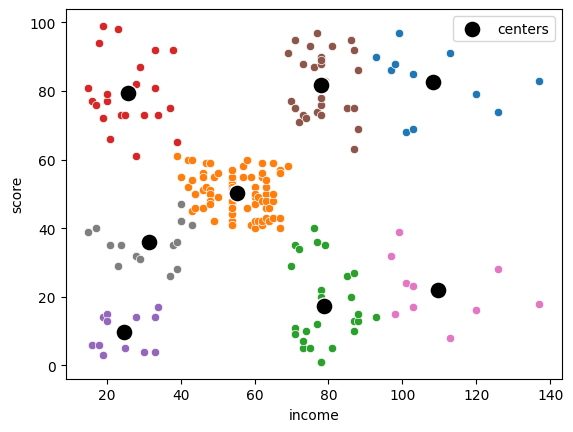

In [ ]:
sns.scatterplot(x = df0["income"], y = df0["score"])
sns.scatterplot(x = df1["income"], y = df1["score"])
sns.scatterplot(x = df2["income"], y = df2["score"])
sns.scatterplot(x = df3["income"], y = df3["score"])
sns.scatterplot(x = df4["income"], y = df4["score"])
sns.scatterplot(x = df5["income"], y = df5["score"])
sns.scatterplot(x = df6["income"], y = df6["score"])
sns.scatterplot(x = df7["income"], y = df7["score"])

sns.scatterplot(x = center1[:,0], y = center1[:,1], label = "centers", s = 150, color = "black")  # [:,0] this means all row, 0 number column

In [ ]:
# elbow method for finding the cluster size

wcss = []

cluster_number = range (2,25)
for cluster in cluster_number:
    Km = KMeans(n_clusters= cluster, random_state=42, n_init= 10)
    model1 = Km.fit(df[["income", "score"]])
    wcss.append(model1.inertia_)


In [ ]:
wcss

[181363.59595959593,
 106348.37306211118,
 73679.78903948836,
 44448.45544793371,
 37233.81451071001,
 30241.343617936593,
 25036.41760403398,
 21916.794789843727,
 20072.070939404006,
 17511.7418692661,
 15801.68699279506,
 14293.14305433129,
 12775.343451156685,
 11899.785593328239,
 11287.824178014967,
 10146.145713083213,
 9378.959007659007,
 8744.888892153598,
 8214.423788638262,
 7867.851365556538,
 7176.443098568098,
 6799.256296662275,
 6355.571381886088]

<Axes: >

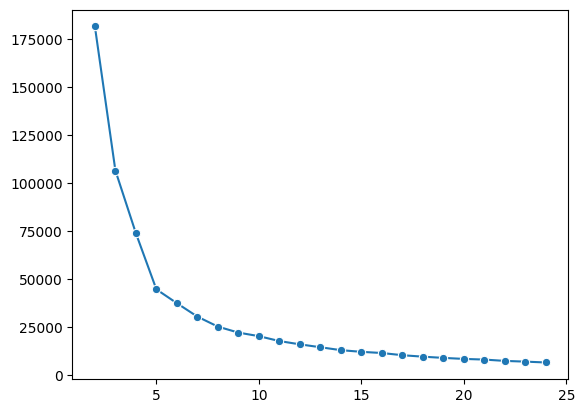

In [ ]:
sns.lineplot(x=cluster_number, y=wcss, marker="o")

In [ ]:
fig = KneeLocator(cluster_number, wcss, curve = "convex", direction = "decreasing", S= 1.0)

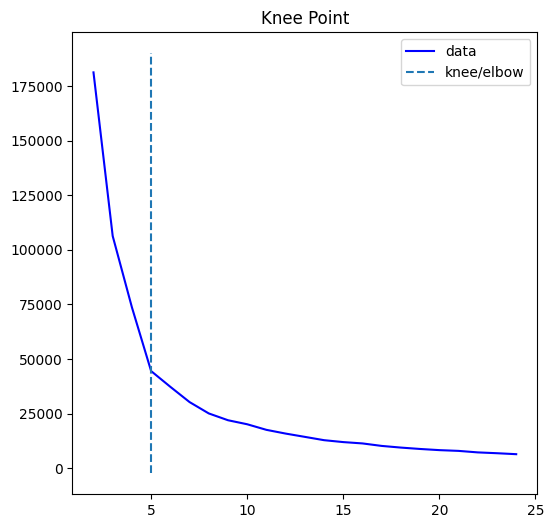

In [ ]:
fig.plot_knee()


In [ ]:
fig.all_elbows

{np.int64(5)}

In [ ]:
k_means = KMeans(n_clusters=5, random_state= 42, n_init = 10) 
model2 = k_means.fit(new_df[["income", "score"]])

In [ ]:
new_df["pred"] = model2.predict(new_df[["income", "score"]])

In [ ]:
new_df.head()

,CustomerID,Gender,Age,income,score,pred
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
new_df[new_df["pred"]==0]

,CustomerID,Gender,Age,income,score,pred
43,44,Female,31,39,61,0
46,47,Female,50,40,55,0
47,48,Female,27,40,47,0
48,49,Female,29,40,42,0
49,50,Female,31,40,42,0
...,...,...,...,...,...,...
121,122,Female,38,67,40,0
122,123,Female,40,69,58,0
126,127,Male,43,71,35,0
132,133,Female,25,72,34,0


In [ ]:
new_df0 = new_df[new_df["pred"] == 0]
new_df1 = new_df[new_df["pred"] == 1]
new_df2 = new_df[new_df["pred"] == 2]
new_df3 = new_df[new_df["pred"] == 3]
new_df4 = new_df[new_df["pred"] == 4]

In [ ]:
center2 = model2. cluster_centers_
center2

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

Text(45, 105, 'Before adding new data point')

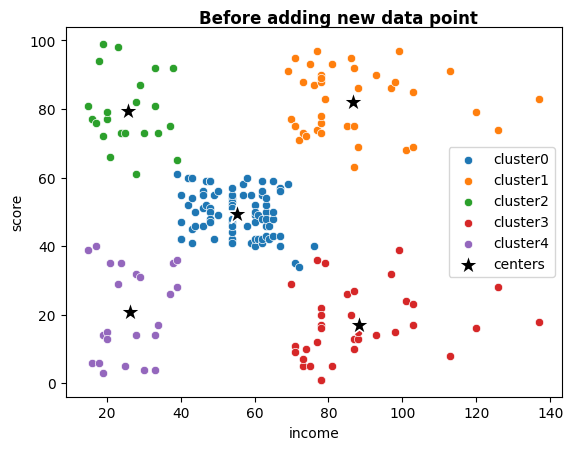

In [ ]:
sns.scatterplot(x = new_df0["income"], y = new_df0["score"], label  = "cluster0")
sns.scatterplot(x = new_df1["income"], y = new_df1["score"], label  = "cluster1")
sns.scatterplot(x = new_df2["income"], y = new_df2["score"], label  = "cluster2")
sns.scatterplot(x = new_df3["income"], y = new_df3["score"], label  = "cluster3")
sns.scatterplot(x = new_df4["income"], y = new_df4["score"], label  = "cluster4")

sns.scatterplot(x = center2[:,0], y = center2[:,1], label = "centers", s = 250, color = "black", marker = "*")  # [:,0] this means all row, 0 number column

plt.text(
    45,105,
    "Before adding new data point", 
    fontsize=12, 
    fontweight='bold',
    color='black'
)

# working with new data

In [ ]:
new_income = 60
new_score = 60
new_customer = [[new_income, new_score]]
pred_cluster = model2.predict(new_customer)[0]
print(pred_cluster)


0


c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


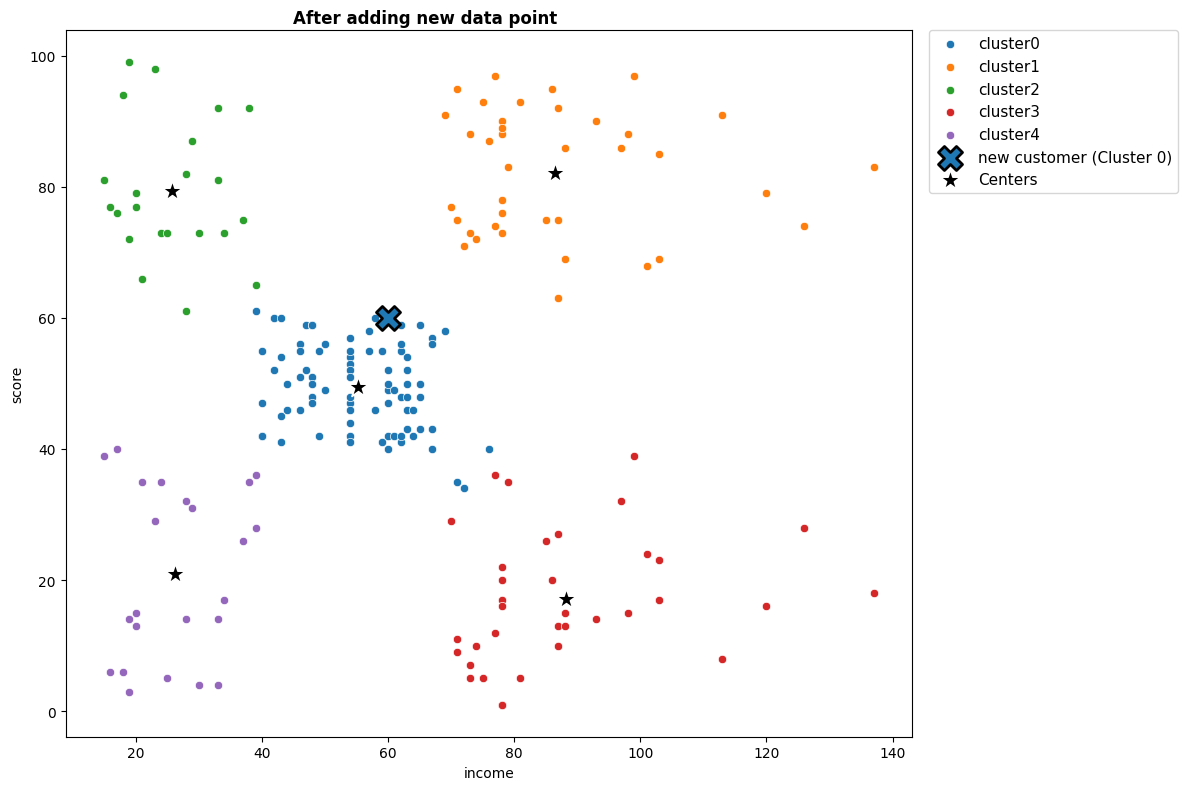

In [ ]:
# plot cluster
plt.figure(figsize=(12,8))

sns.scatterplot(x = new_df0["income"], y = new_df0["score"], label  = "cluster0")
sns.scatterplot(x = new_df1["income"], y = new_df1["score"], label  = "cluster1")
sns.scatterplot(x = new_df2["income"], y = new_df2["score"], label  = "cluster2")
sns.scatterplot(x = new_df3["income"], y = new_df3["score"], label  = "cluster3")
sns.scatterplot(x = new_df4["income"], y = new_df4["score"], label  = "cluster4")

# Highlight new predicted point 
sns.scatterplot(
    x=[new_income], 
    y=[new_score], 
    color=sns.color_palette()[pred_cluster],
    edgecolor="black",
    linewidth=2,
    marker="X", 
    s=300, 
    label=f"new customer (Cluster {pred_cluster})"
)
# centroids
center3 = model2.cluster_centers_
sns.scatterplot(
    x=center3[:, 0],
    y=center3[:, 1],
    label="Centers",
    s=250,
    color="black",
    marker="*"
)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)

plt.text(
    45,105,
    "After adding new data point", 
    fontsize=12, 
    fontweight='bold',
    color='black'
)

# Prevents the right layout edge from getting cropped
plt.tight_layout()
plt.show()